<a href="https://colab.research.google.com/github/MainCodePilot/activity-rec/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Configuration

A shared configuration block was used across the whole project so that key settings such as file paths, image size, batch size, learning rate, number of epochs, and class labels were defined once and reused in all subtasks. This makes the notebook more consistent, easier to update, and more reproducible.

## Subtask 1: Baseline Models

For Subtask 1, two baseline models were developed: **FNN_base** and **CNN_base**. These models were trained only on the provided activity images, following the assignment requirement to compare a feedforward neural network and a convolutional neural network on the same classification task. :contentReference[oaicite:0]{index=0}

## Why the Baseline Accuracy Was Low

The results showed relatively low accuracy for both baseline models. This is expected because the dataset is challenging and the images differ in background, object position, scale, and overall appearance. Although the images were resized to a fixed input size before training, the original visual variation in the dataset still makes classification difficult, especially for simple baseline models. :contentReference[oaicite:1]{index=1}

## Interpretation of FNN_base and CNN_base

The **FNN_base** model uses flattened pixel values, so it does not preserve the spatial structure of the image. This limits its ability to learn meaningful visual patterns. The **CNN_base** model is more suitable for images because it learns local features through convolution layers, but in this baseline setup its performance was still limited by the small and visually varied dataset.

## Why Subtask 1 Is Still Important

Even though the baseline results were not strong, Subtask 1 is still important because it provides a reference point for the rest of the project. It shows the initial performance level before any improvements are applied and helps justify the need for more advanced methods in the next stage.

## Link to Subtask 2

The outcome of Subtask 1 motivates Subtask 2, where the CNN model will be improved using generalisation techniques such as augmentation, regularisation, and better training strategies. Therefore, the low baseline accuracy is not a failure, but a useful starting point for showing how later methods improve performance. :contentReference[oaicite:2]{index=2}

# **Create subtask1.py**

In [1]:
# ========================= CELL 1 =========================
%%writefile /content/subtask1.py
# /content/subtask1.py

from __future__ import annotations

import copy
import json
import os
import random
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_json(data: dict[str, Any], path: str | Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


class ActivityDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        image_col: str,
        label_index_col: str,
        transform: transforms.Compose,
    ) -> None:
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_col = image_col
        self.label_index_col = label_index_col
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        row = self.dataframe.iloc[idx]
        image_path = row[self.image_col]
        label = int(row[self.label_index_col])

        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return image_tensor, label_tensor


class FNNBase(nn.Module):
    def __init__(
        self,
        input_height: int,
        input_width: int,
        input_channels: int,
        hidden_units: list[int],
        num_classes: int,
    ) -> None:
        super().__init__()
        input_dim = input_height * input_width * input_channels
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_units[0]),
            nn.ReLU(),
            nn.Linear(hidden_units[0], hidden_units[1]),
            nn.ReLU(),
            nn.Linear(hidden_units[1], num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class CNNBase(nn.Module):
    def __init__(
        self,
        input_channels: int,
        conv1_out_channels: int,
        conv2_out_channels: int,
        conv3_out_channels: int,
        kernel_size: int,
        padding: int,
        pool_kernel_size: int,
        linear_units: int,
        num_classes: int,
    ) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, conv1_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv1_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.Conv2d(conv1_out_channels, conv2_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv2_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.Conv2d(conv2_out_channels, conv3_out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv3_out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=pool_kernel_size),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv3_out_channels, linear_units),
            nn.ReLU(),
            nn.Linear(linear_units, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


def validate_config(config: dict[str, Any]) -> None:
    required = [
        "csv_path",
        "img_dir",
        "models_dir",
        "outputs_dir",
        "image_col",
        "label_col",
        "class_names",
        "num_classes",
        "random_seed",
        "val_split",
        "test_split",
        "image_size",
        "num_channels",
        "batch_size",
        "epochs",
        "learning_rate",
        "device",
        "num_workers",
        "fnn_hidden_units",
        "cnn_conv1_out_channels",
        "cnn_conv2_out_channels",
        "cnn_conv3_out_channels",
        "cnn_kernel_size",
        "cnn_padding",
        "cnn_pool_kernel_size",
        "cnn_linear_units",
    ]
    missing = [k for k in required if k not in config]
    if missing:
        raise ValueError(f"Missing config keys: {missing}")


def load_dataframe(config: dict[str, Any]) -> pd.DataFrame:
    df = pd.read_csv(config["csv_path"]).copy()
    df = df[[config["image_col"], "coco_url", config["label_col"]]].dropna().copy()
    df[config["image_col"]] = df[config["image_col"]].astype(str).str.strip()
    df[config["label_col"]] = df[config["label_col"]].astype(str).str.strip()

    label_to_index = {label: idx for idx, label in enumerate(config["class_names"])}
    df["label_idx"] = df[config["label_col"]].map(label_to_index)

    if df["label_idx"].isna().any():
        bad = df[df["label_idx"].isna()][config["label_col"]].unique().tolist()
        raise ValueError(f"Unexpected labels found: {bad}")

    df["label_idx"] = df["label_idx"].astype(int)
    df["image_path"] = df[config["image_col"]].apply(
        lambda x: str(Path(config["img_dir"]) / x)
    )
    return df


def download_missing_images(
    df: pd.DataFrame,
    image_path_col: str,
    url_col: str,
    timeout_seconds: int = 30,
) -> None:
    missing_df = df[~df[image_path_col].map(os.path.exists)].copy()
    if missing_df.empty:
        print("All images already exist.")
        return

    print(f"Downloading {len(missing_df)} missing images...")
    session = requests.Session()

    for _, row in missing_df.iterrows():
        image_path = Path(row[image_path_col])
        image_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            response = session.get(row[url_col], timeout=timeout_seconds)
            response.raise_for_status()
            with open(image_path, "wb") as f:
                f.write(response.content)
        except Exception as exc:
            print(f"Download failed for {image_path.name}: {exc}")


def filter_existing_images(df: pd.DataFrame, image_path_col: str) -> pd.DataFrame:
    filtered = df[df[image_path_col].map(os.path.exists)].copy().reset_index(drop=True)
    if filtered.empty:
        raise ValueError("No images found after filtering existing files.")
    return filtered


def make_splits(df: pd.DataFrame, config: dict[str, Any]):
    train_df, temp_df = train_test_split(
        df,
        test_size=(config["val_split"] + config["test_split"]),
        random_state=config["random_seed"],
        stratify=df["label_idx"],
    )

    rel_test = config["test_split"] / (config["val_split"] + config["test_split"])

    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        random_state=config["random_seed"],
        stratify=temp_df["label_idx"],
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def build_transform(config: dict[str, Any]) -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize(config["image_size"]),
            transforms.ToTensor(),
        ]
    )


def build_dataloaders(train_df, val_df, test_df, config: dict[str, Any]):
    transform = build_transform(config)

    train_ds = ActivityDataset(train_df, "image_path", "label_idx", transform)
    val_ds = ActivityDataset(val_df, "image_path", "label_idx", transform)
    test_ds = ActivityDataset(test_df, "image_path", "label_idx", transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )

    return train_loader, val_loader, test_loader


def build_model(model_name: str, config: dict[str, Any]) -> nn.Module:
    if model_name == "FNN_base":
        return FNNBase(
            input_height=config["image_size"][0],
            input_width=config["image_size"][1],
            input_channels=config["num_channels"],
            hidden_units=config["fnn_hidden_units"],
            num_classes=config["num_classes"],
        )

    if model_name == "CNN_base":
        return CNNBase(
            input_channels=config["num_channels"],
            conv1_out_channels=config["cnn_conv1_out_channels"],
            conv2_out_channels=config["cnn_conv2_out_channels"],
            conv3_out_channels=config["cnn_conv3_out_channels"],
            kernel_size=config["cnn_kernel_size"],
            padding=config["cnn_padding"],
            pool_kernel_size=config["cnn_pool_kernel_size"],
            linear_units=config["cnn_linear_units"],
            num_classes=config["num_classes"],
        )

    raise ValueError(f"Unknown model name: {model_name}")


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

    return total_loss / total_count, total_correct / total_count, y_true, y_pred


@torch.no_grad()
def collect_predictions_and_images(model, loader, device):
    model.eval()
    all_images = []
    all_true = []
    all_pred = []

    for images, labels in loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()

        all_images.append(images.cpu())
        all_true.extend(labels.numpy().tolist())
        all_pred.extend(preds.numpy().tolist())

    return torch.cat(all_images, dim=0), all_true, all_pred


def compute_metrics(y_true, y_pred, class_names):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0,
            output_dict=True,
        ),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def plot_class_distribution(df, config, save_path):
    counts = df[config["label_col"]].value_counts().reindex(config["class_names"])
    plt.figure(figsize=(7, 4))
    plt.bar(counts.index, counts.values)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_sample_images(df, config, save_path, n_per_class=3):
    rows = len(config["class_names"])
    cols = n_per_class
    plt.figure(figsize=(12, 8))
    plot_idx = 1

    for class_name in config["class_names"]:
        subset = df[df[config["label_col"]] == class_name].head(n_per_class)
        for _, row in subset.iterrows():
            image = Image.open(row["image_path"]).convert("RGB")
            plt.subplot(rows, cols, plot_idx)
            plt.imshow(image)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_history(history, model_name, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_confusion(cm, class_names, title, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_misclassified_examples(images, y_true, y_pred, class_names, title, save_path, max_items=9):
    wrong_idx = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p][:max_items]

    if not wrong_idx:
        print(f"{title}: no misclassified examples to plot.")
        return

    plt.figure(figsize=(12, 8))
    for plot_i, idx in enumerate(wrong_idx, start=1):
        image = images[idx].permute(1, 2, 0).numpy()
        image = np.clip(image, 0, 1)
        plt.subplot(3, 3, plot_i)
        plt.imshow(image)
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def train_model(model_name, config, train_loader, val_loader, test_loader):
    device = config["device"]
    model = build_model(model_name, config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate_one_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{model_name} | Epoch {epoch:02d}/{config['epochs']:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    _, _, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion, device)
    _, _, test_true, test_pred = evaluate_one_epoch(model, test_loader, criterion, device)

    val_metrics = compute_metrics(val_true, val_pred, config["class_names"])
    test_metrics = compute_metrics(test_true, test_pred, config["class_names"])

    outputs_dir = ensure_dir(config["outputs_dir"])
    models_dir = ensure_dir(config["models_dir"])

    plot_history(history, model_name, outputs_dir / f"{model_name}_history.png")
    plot_confusion(
        val_metrics["confusion_matrix"],
        config["class_names"],
        f"{model_name} Validation Confusion Matrix",
        outputs_dir / f"{model_name}_val_confusion.png",
    )
    plot_confusion(
        test_metrics["confusion_matrix"],
        config["class_names"],
        f"{model_name} Test Confusion Matrix",
        outputs_dir / f"{model_name}_test_confusion.png",
    )

    test_images, test_true_list, test_pred_list = collect_predictions_and_images(model, test_loader, device)
    plot_misclassified_examples(
        test_images,
        test_true_list,
        test_pred_list,
        config["class_names"],
        f"{model_name} Misclassified Test Images",
        outputs_dir / f"{model_name}_misclassified.png",
    )

    torch.save(model.state_dict(), models_dir / f"{model_name}.pt")
    pd.DataFrame(val_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / f"{model_name}_val_report.csv"
    )
    pd.DataFrame(test_metrics["classification_report"]).transpose().to_csv(
        outputs_dir / f"{model_name}_test_report.csv"
    )

    return {
        "model_name": model_name,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


def run_subtask1(config: dict[str, Any]):
    validate_config(config)
    set_seed(config["random_seed"])
    ensure_dir(config["img_dir"])
    ensure_dir(config["models_dir"])
    ensure_dir(config["outputs_dir"])

    df = load_dataframe(config)

    if config.get("download_missing_images", True):
        download_missing_images(df, "image_path", "coco_url", config.get("download_timeout_seconds", 30))

    df = filter_existing_images(df, "image_path")

    print("Usable images:", len(df))
    print(df[config["label_col"]].value_counts())

    if len(df) < 250:
        print("Warning: usable image count is low. Accuracy may be poor because many downloads failed.")

    outputs_dir = ensure_dir(config["outputs_dir"])
    plot_class_distribution(df, config, outputs_dir / "class_distribution.png")
    plot_sample_images(df, config, outputs_dir / "sample_images.png", n_per_class=3)

    train_df, val_df, test_df = make_splits(df, config)
    print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

    train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df, config)

    fnn_results = train_model("FNN_base", config, train_loader, val_loader, test_loader)
    cnn_results = train_model("CNN_base", config, train_loader, val_loader, test_loader)

    comparison_df = pd.DataFrame(
        [
            {
                "model": fnn_results["model_name"],
                "val_accuracy": fnn_results["val_metrics"]["accuracy"],
                "val_macro_f1": fnn_results["val_metrics"]["macro_f1"],
                "test_accuracy": fnn_results["test_metrics"]["accuracy"],
                "test_macro_f1": fnn_results["test_metrics"]["macro_f1"],
            },
            {
                "model": cnn_results["model_name"],
                "val_accuracy": cnn_results["val_metrics"]["accuracy"],
                "val_macro_f1": cnn_results["val_metrics"]["macro_f1"],
                "test_accuracy": cnn_results["test_metrics"]["accuracy"],
                "test_macro_f1": cnn_results["test_metrics"]["macro_f1"],
            },
        ]
    ).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

    comparison_df.to_csv(outputs_dir / "subtask1_model_comparison.csv", index=False)
    save_json(
        {
            "usable_images": int(len(df)),
            "train_size": int(len(train_df)),
            "val_size": int(len(val_df)),
            "test_size": int(len(test_df)),
        },
        outputs_dir / "subtask1_summary.json",
    )

    print("\nFinal comparison")
    print(comparison_df)
    return comparison_df


Writing /content/subtask1.py


# ===============================================================
# +--------------------[ START:PROJECT CONFIGURATION ]--------------------- +
# ===============================================================

In [2]:
# ========================= CELL 2 =========================
import importlib
import torch
import subtask1

importlib.reload(subtask1)

CONFIG = {
    # =============================================================
    # +----------------------------[ START:PROJECT CONFIGURATION ] -------------------+
    # ==============================================================
    "project_name": "subtask1_cnn_vs_fnn",
    "task_name": "human_activity_classification",
    "framework": "pytorch",
    "random_seed": 42,

    "csv_path": "/content/image_url.csv",
    "img_dir": "/content/images",
    "models_dir": "/content/models",
    "outputs_dir": "/content/outputs",

    "image_col": "file_name",
    "label_col": "label",
    "class_names": ["sitting", "standing", "walking_running"],
    "num_classes": 3,

    "val_split": 0.15,
    "test_split": 0.15,

    "image_size": (128, 128),
    "num_channels": 3,

    "batch_size": 16,
    "num_workers": 0,

    "epochs": 30,
    "learning_rate": 3e-4,

    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "download_missing_images": True,
    "download_timeout_seconds": 30,

    "fnn_hidden_units": [256, 128],

    "cnn_conv1_out_channels": 32,
    "cnn_conv2_out_channels": 64,
    "cnn_conv3_out_channels": 128,
    "cnn_kernel_size": 3,
    "cnn_padding": 1,
    "cnn_pool_kernel_size": 2,
    "cnn_linear_units": 256,
    # =============================================================
    # +----------------------------[ END:PROJECT CONFIGURATION ] ---------------------+
    # ==============================================================
}


# ===============================================================
# +--------------------[ START:PROJECT CONFIGURATION ]--------------------- +
# ===============================================================

Usable images: 285
label
walking_running    98
sitting            95
standing           92
Name: count, dtype: int64


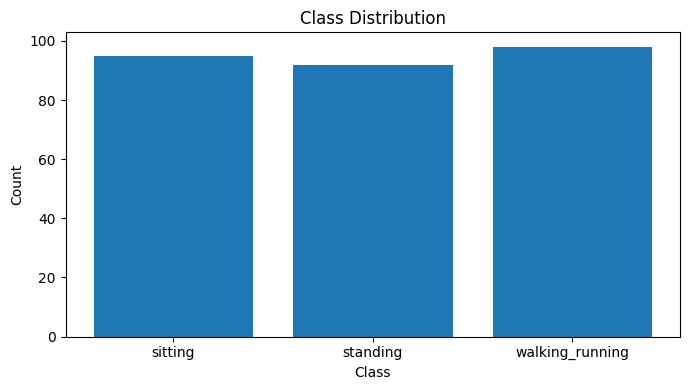

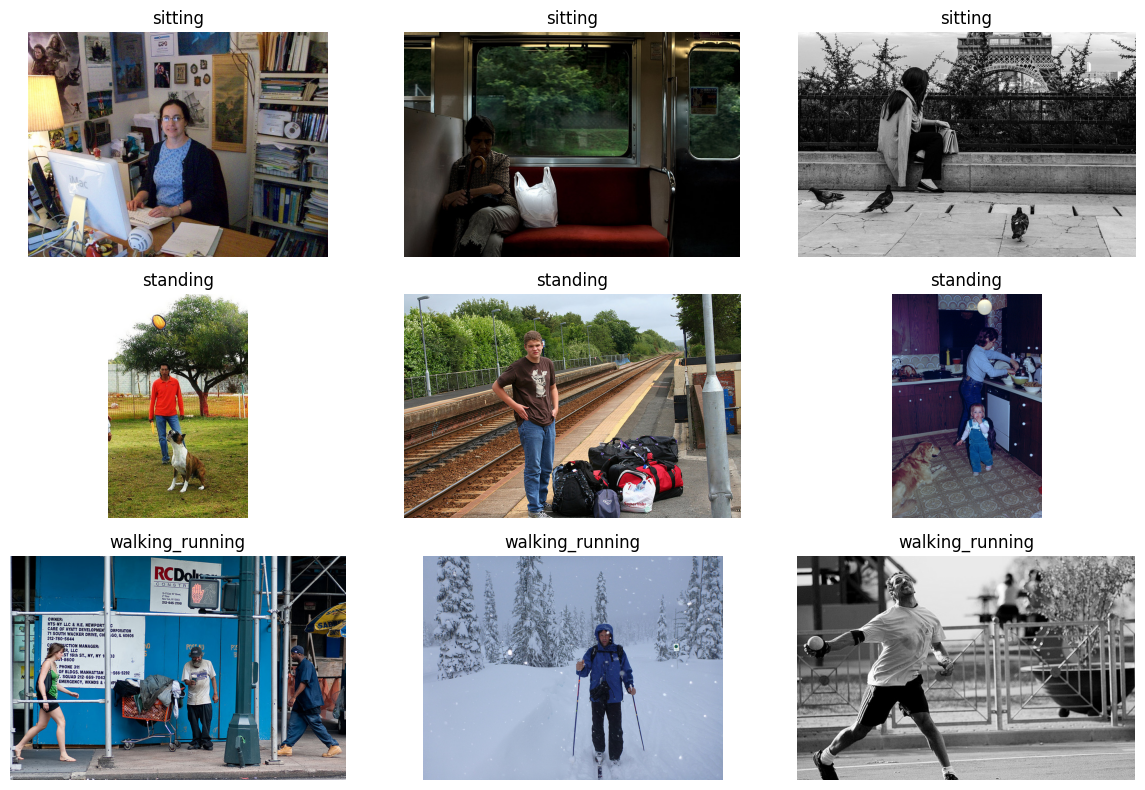

Train: 199 Val: 43 Test: 43
FNN_base | Epoch 01/30 | train_loss=1.6713 train_acc=0.3819 | val_loss=1.1833 val_acc=0.3256
FNN_base | Epoch 02/30 | train_loss=1.1777 train_acc=0.3317 | val_loss=1.1584 val_acc=0.3488
FNN_base | Epoch 03/30 | train_loss=1.1062 train_acc=0.4171 | val_loss=1.1627 val_acc=0.3488
FNN_base | Epoch 04/30 | train_loss=1.0308 train_acc=0.4724 | val_loss=1.2058 val_acc=0.3488
FNN_base | Epoch 05/30 | train_loss=1.0720 train_acc=0.3869 | val_loss=1.2474 val_acc=0.3488
FNN_base | Epoch 06/30 | train_loss=0.9679 train_acc=0.5477 | val_loss=1.2948 val_acc=0.3721
FNN_base | Epoch 07/30 | train_loss=0.9238 train_acc=0.6131 | val_loss=1.2533 val_acc=0.3953
FNN_base | Epoch 08/30 | train_loss=0.8935 train_acc=0.5930 | val_loss=1.1283 val_acc=0.3721
FNN_base | Epoch 09/30 | train_loss=0.8090 train_acc=0.7236 | val_loss=1.1160 val_acc=0.3488
FNN_base | Epoch 10/30 | train_loss=0.7890 train_acc=0.6985 | val_loss=1.1551 val_acc=0.3023
FNN_base | Epoch 11/30 | train_loss=0.7368

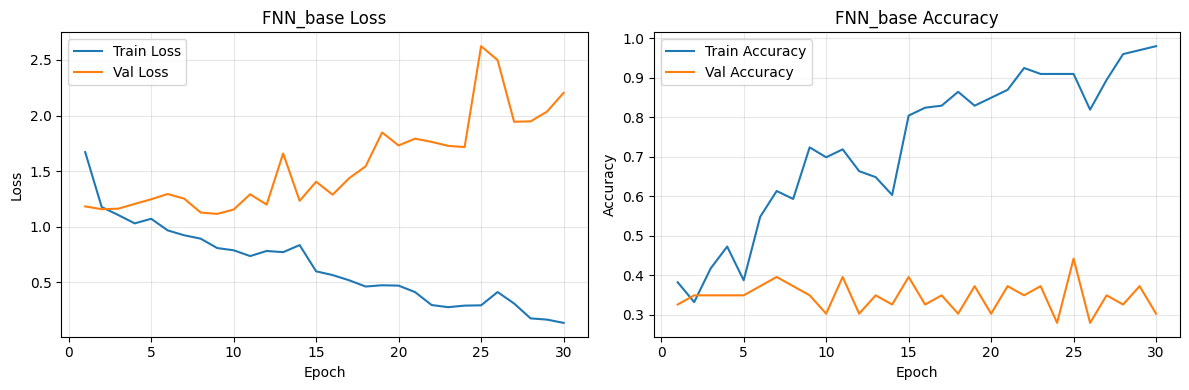

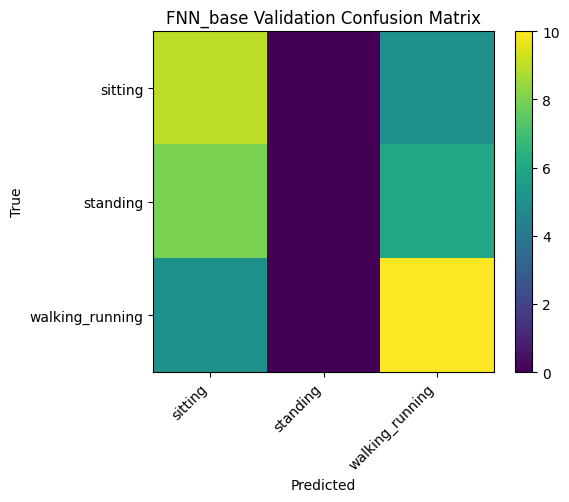

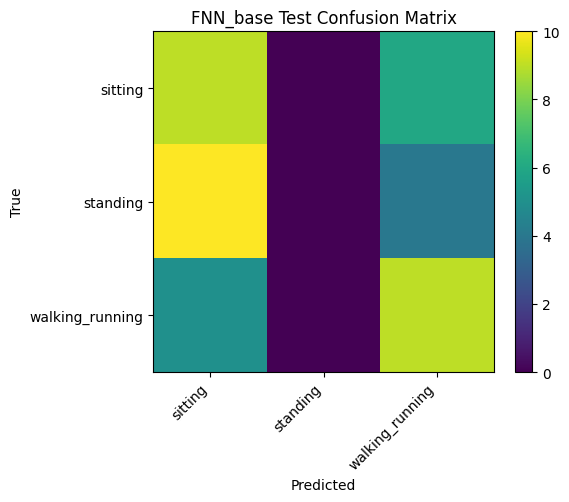

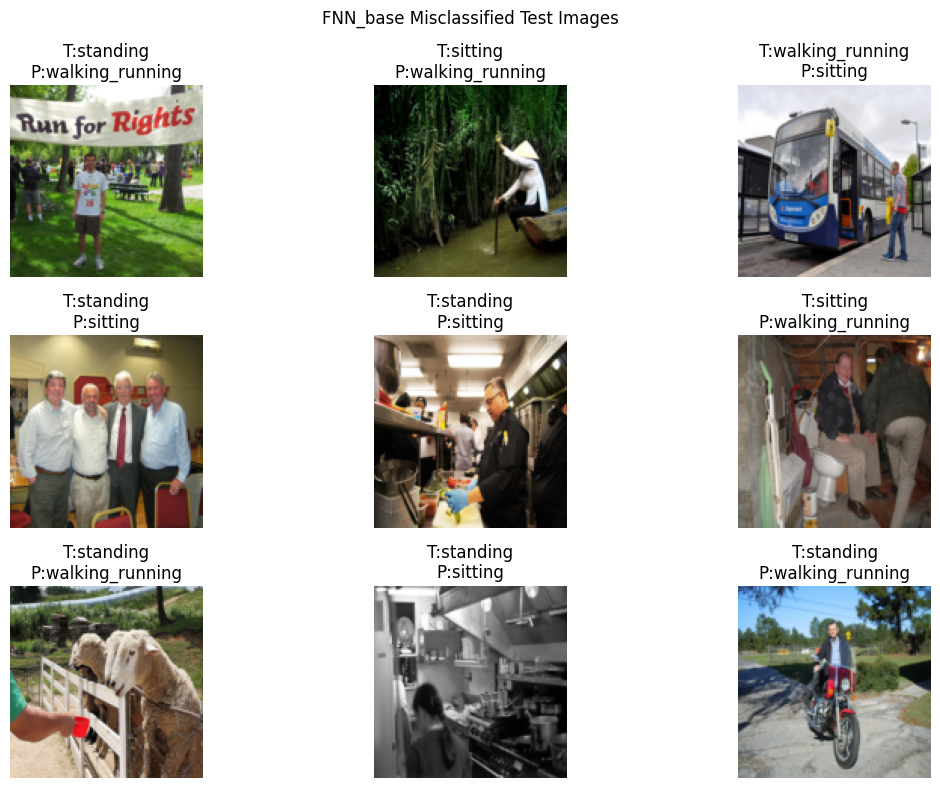

CNN_base | Epoch 01/30 | train_loss=1.1096 train_acc=0.3618 | val_loss=1.1025 val_acc=0.3488
CNN_base | Epoch 02/30 | train_loss=1.0686 train_acc=0.4121 | val_loss=1.1209 val_acc=0.3488
CNN_base | Epoch 03/30 | train_loss=1.0498 train_acc=0.4171 | val_loss=1.1342 val_acc=0.3721
CNN_base | Epoch 04/30 | train_loss=1.0374 train_acc=0.4322 | val_loss=1.1591 val_acc=0.4186
CNN_base | Epoch 05/30 | train_loss=1.0249 train_acc=0.4925 | val_loss=1.1541 val_acc=0.2093
CNN_base | Epoch 06/30 | train_loss=1.0244 train_acc=0.4472 | val_loss=1.1688 val_acc=0.3488
CNN_base | Epoch 07/30 | train_loss=1.0165 train_acc=0.4874 | val_loss=1.1331 val_acc=0.3488
CNN_base | Epoch 08/30 | train_loss=0.9956 train_acc=0.4925 | val_loss=1.1462 val_acc=0.3488
CNN_base | Epoch 09/30 | train_loss=0.9985 train_acc=0.4874 | val_loss=1.1756 val_acc=0.3023
CNN_base | Epoch 10/30 | train_loss=0.9860 train_acc=0.5126 | val_loss=1.1440 val_acc=0.3023
CNN_base | Epoch 11/30 | train_loss=0.9902 train_acc=0.5327 | val_loss

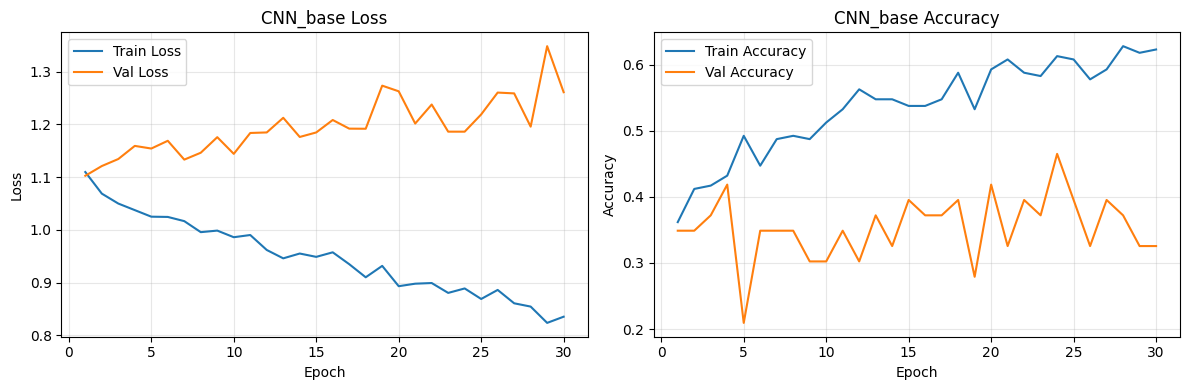

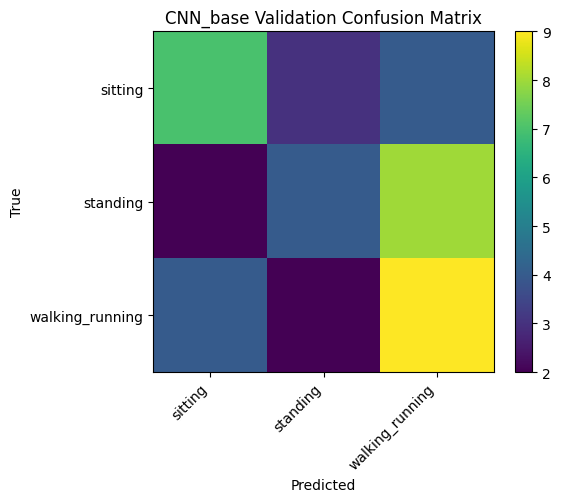

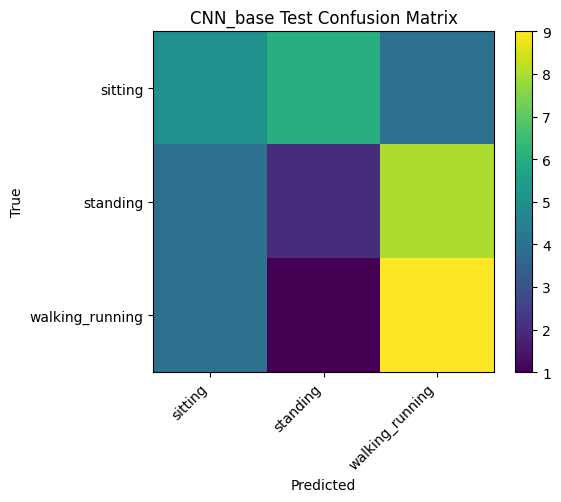

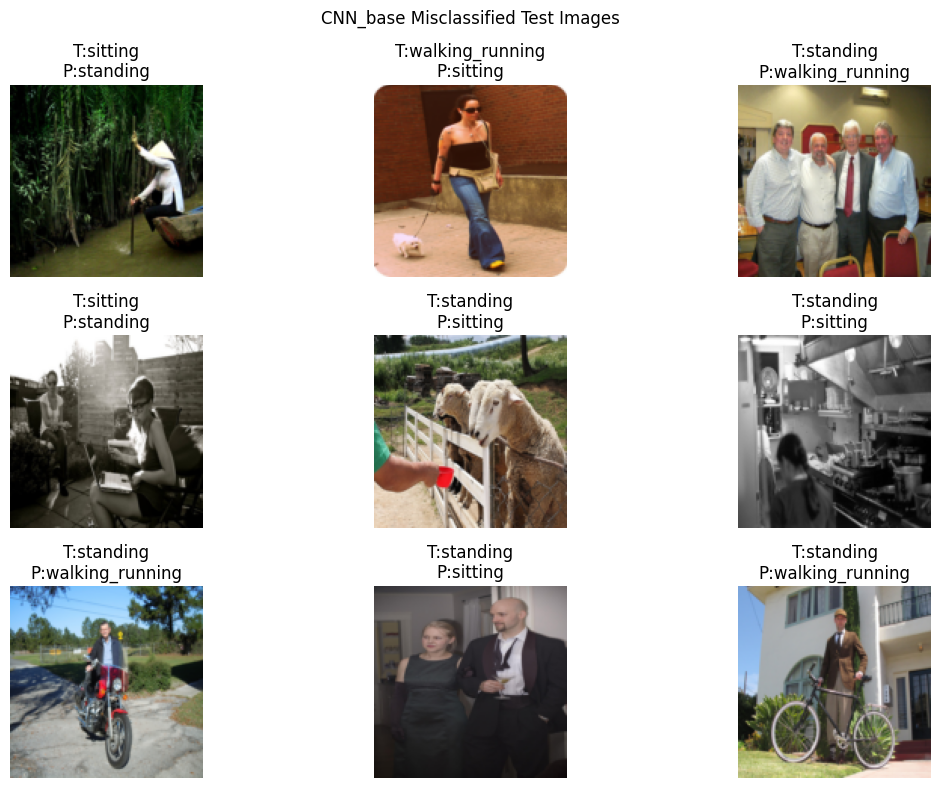


Final comparison
      model  val_accuracy  val_macro_f1  test_accuracy  test_macro_f1
0  FNN_base      0.441860      0.351852       0.418605       0.335664
1  CNN_base      0.465116      0.455448       0.372093       0.348447
Models: ['FNN_base.pt', 'CNN_base.pt']
Outputs: ['CNN_base_val_confusion.png', 'CNN_base_test_confusion.png', 'FNN_base_test_report.csv', 'FNN_base_val_confusion.png', 'FNN_base_test_confusion.png', 'CNN_base_val_report.csv', 'subtask1_summary.json', 'CNN_base_history.png', 'class_distribution.png', 'FNN_base_val_report.csv', 'sample_images.png', 'CNN_base_test_report.csv', 'subtask1_model_comparison.csv', 'CNN_base_misclassified.png', 'FNN_base_history.png', 'FNN_base_misclassified.png']


In [3]:
comparison_df = subtask1.run_subtask1(CONFIG)
comparison_df


# ========================= CELL 3 =========================
import os
print("Models:", os.listdir("/content/models"))
print("Outputs:", os.listdir("/content/outputs"))